# K Means for Iris Datasets


In [8]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [9]:
iris = load_iris()

In [23]:
X = iris.data
y = iris.target


<Axes: >

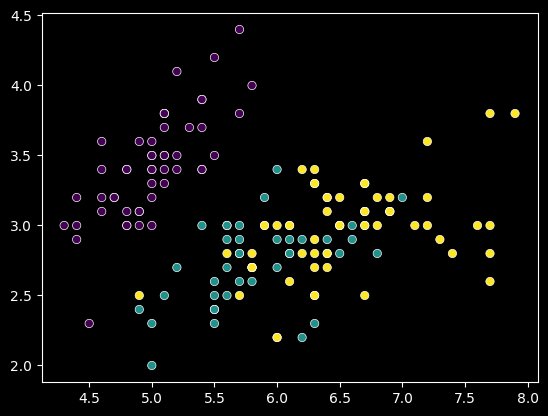

In [25]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c= y)

## Data Scaling


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Find K


In [29]:
#elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)

In [30]:
wcss

[600.0000000000001,
 222.36170496502302,
 139.82049635974982,
 114.35385298004145,
 90.80728315078542,
 82.69649754508714,
 73.7875543614092,
 62.23590571911791,
 62.074292659243994,
 48.78613690561771]

<Axes: >

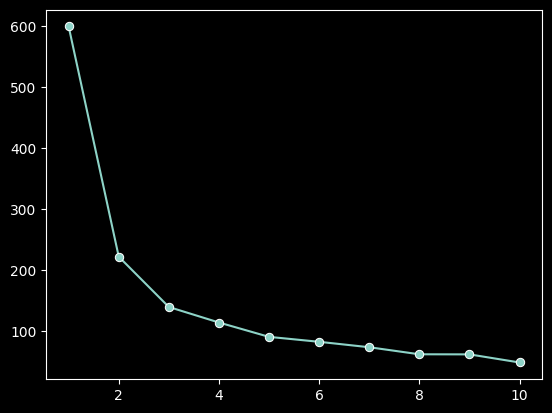

In [33]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')

<Axes: >

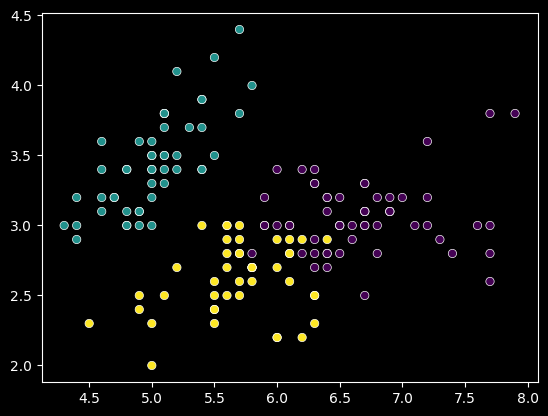

In [34]:
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X[:, 0], y=X[:,1], c=labels)

## Dimension Reduction


In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)#reduced to 2
pca_data = pca.fit_transform(X_scaled)



<Axes: >

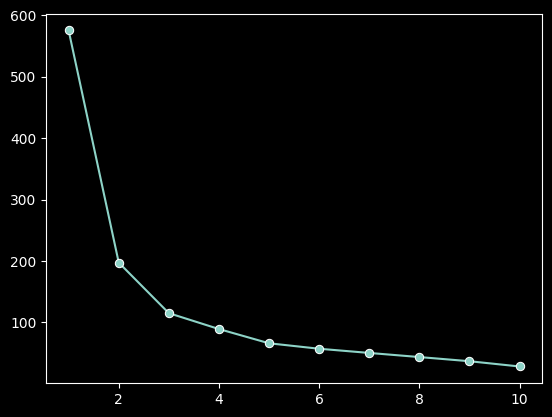

In [37]:
#elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1,11), y=wcss, marker='o')

<Axes: >

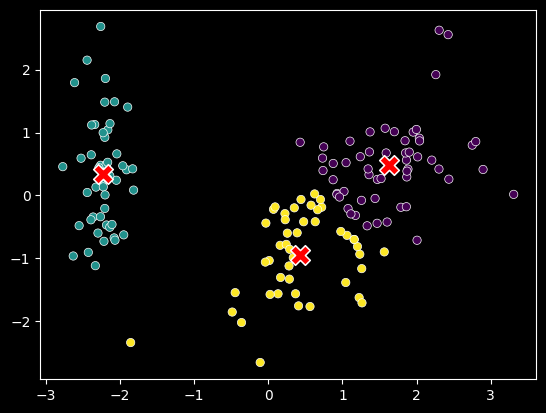

In [42]:
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:, 1], c="red", s= 200, marker="X")

<Axes: >

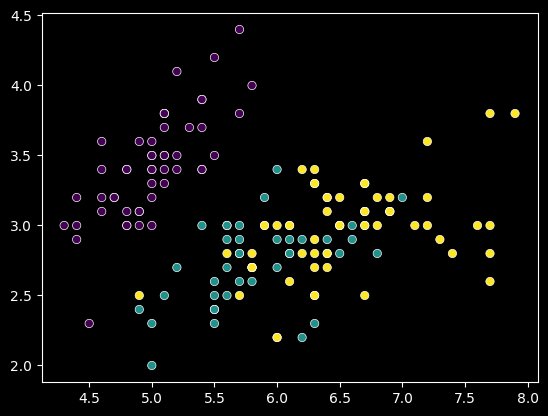

In [40]:
sns.scatterplot(x=X[:, 0], y=X[:,1], c=y)